# R18 entailment sufficiency instrument - H172 & H176

**Round R18 - executor batch 2026-07-07.** Two linked hypotheses on the *sufficiency scorer* that every probe-level
measurement inherits.

- **R18-H172** - replace the degenerate fuzzy evidence matcher (`value_tokens("SD card: > 1 year") == ["1"]`, degenerate on
  17/33 short-numeric golds) with an **NLI entailment scorer** (mDeBERTa cross-encoder) over (rendered context, gold) pairs.
  Clauses: (a) non-degenerate on the 17 problem golds, (b) >=90% agreement with manual adjudication on a 50-pair audit
  (refuted <80%), (c) <100ms/pair; then re-run H81's headline (baseline recall + greedy recall-at-knee) under it.
- **R18-H176** - replace H85's near-saturated binary per-type sufficiency with a **graded** scorer; clauses: variance
  restored (CoV>=0.2 across types) + independence survives (|r|<0.3 vs per-type Good-Turing missing mass, bootstrap CI
  excluding |r|>0.5). H176 consumes H172's scorer, or the token-coverage fallback if H172 fails clause (b).

Graph: **read-only neo4j2** (10-doc CPAP). Original **33-gold** probe set (R19-H186 refuted graph-derived golds).
GPU: index 2 (RTX 5000 Ada, sm_89), fp16 + eager attention (transformers 5.13 has no SDPA path for DebertaV2).

In [1]:
# GPU selection FIRST - set CUDA env before importing torch (nvidia-smi index 2 = RTX 5000 Ada, sm_89)
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="2"
os.environ["HF_HUB_OFFLINE"]="1"                      # model is cached; no network
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from rich import print as rprint

NLI_MODEL="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"   # 3-label NLI cross-encoder, cached
nli_tok=AutoTokenizer.from_pretrained(NLI_MODEL)
# Ada recipe: fp16 (not bf16); attn=eager (DebertaV2 has no SDPA kernel in transformers 5.13);
# quantization skipped (disentangled attention is attention-heavy, linear-quant buys nothing); compile skipped
# (eager DeBERTa gains little and risks a compile hang - per-pair latency already passes the <100ms bar).
nli_model=AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL, dtype=torch.float16, attn_implementation="eager").to("cuda").eval()
ENT_IDX=[i for i,l in nli_model.config.id2label.items() if l=="entailment"][0]  # softmax index for entailment
rprint(f"[green]NLI[/green] {NLI_MODEL} | id2label={nli_model.config.id2label} | entailment idx={ENT_IDX} | "
       f"{next(nli_model.parameters()).dtype} on {torch.cuda.get_device_name(0)}")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 3566.54it/s]

NLI MoritzLaurer/mDeBERTa-v3-base-mnli-xnli | id2label={0: 'entailment', 1: 'neutral', 2: 'contradiction'} | 
entailment idx=0 | torch.float16 on NVIDIA RTX 5000 Ada Generation

In [2]:
# Imports
import re, json, math, pickle, hashlib, time, datetime
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np, yaml
import matplotlib.pyplot as plt
from rich.progress import Progress

os.environ["NEO4J_URI"]="bolt://user-konrad.jelen-kgf-neo4j2:7687"   # READ-ONLY 10-doc CPAP graph
os.environ["NEO4J_USER"]="neo4j"; os.environ["NEO4J_PASSWORD"]="kgfoundry"
np.random.seed(42)
from knowledge_graph_foundry import load_settings, Foundry
from knowledge_graph_foundry.extraction import generate_embeddings
from knowledge_graph_foundry.graph.graphrag import vector_query
from knowledge_graph_foundry.models import Entity
from neo4j import GraphDatabase

settings=load_settings(Path("../config.yml"))
TOP_K=settings.graphrag.top_k; VEC_INDEX=settings.graphrag.vector_index_name; REL_LIMIT=15
TAU=0.50                                              # NLI entailment decision threshold (standard NLI boundary)
rprint(f"[cyan]config[/cyan] top_k={TOP_K} rel_cap={REL_LIMIT} tau={TAU}")

2026-07-07 16:07:29.238 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


config top_k=8 rel_cap=15 tau=0.5

In [3]:
# Deterministic fuzzy-evidence matcher - verbatim from the H34/H61/H81 harness (the instrument H172 retires)
def _norm(s): return re.sub(r"\s+"," ",(s or "").casefold())
def value_tokens(t): return re.findall(r"[\w.\-/]*\d[\w.\-/]*", t)
_UNIT=r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"
def present(gold, ctx):
    ng=_norm(gold)
    if ng in ctx: return True
    sq=re.sub(r"[\s,()]","",ctx); sk=re.sub(r"[\s,()]","",re.sub(_UNIT,"",ng))
    if any(c.isdigit() for c in sk) and len(sk)>=5 and sk in sq: return True
    tok=value_tokens(gold)
    if tok:
        hit=sum(1 for t in tok if _norm(t) in ctx or re.sub(r"[\s,()]","",_norm(t)) in sq)
        return hit>=max(1,len(tok)//2+(len(tok)%2))
    w=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ng)); cw=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ctx))
    return bool(w) and len(w&cw)/len(w)>=0.6
def is_shortnum(g):
    t=value_tokens(g); return bool(t) and sum(len(re.sub(r"[^\d]","",x)) for x in t)<=3
TOK=lambda s: max(1,len(_norm(s))//4)   # ~4 chars/token (H81 token proxy)

In [4]:
# Graph pull (read-only) + render primitives - reused from potentials_r10 / token_economy_r19
d=GraphDatabase.driver(os.environ["NEO4J_URI"], auth=("neo4j","kgfoundry"))
with d.session() as s:
    ents=s.run("MATCH (e:Entity) RETURN e.id AS id,e.name AS name,e.description AS description,"
               "properties(e) AS props,labels(e) AS types").data()
    edges=s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r)<>'SIMILAR_TO' AND a.id<b.id "
                "RETURN DISTINCT a.id AS a,b.id AS b,type(r) AS rel").data()
    prop_rows=s.run("MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid,p.text AS text").data()
    alias_rows=s.run("MATCH (e:Entity)-[:SAME_AS*1..2]-(a:Entity) WHERE e.id<>a.id "
                     "RETURN e.id AS eid,collect(DISTINCT a.id)[..5] AS aliases").data()
d.close()
node={r["id"]:r for r in ents}; names={r["id"]:r["name"] for r in ents}
prim_type={r["id"]:(r["types"][-1] if r["types"] else "Entity") for r in ents}
props_by=defaultdict(list); [props_by[r["eid"]].append(r["text"]) for r in prop_rows]
alias_by={r["eid"]:r["aliases"] for r in alias_rows}
adj=defaultdict(set); rels_by=defaultdict(list)
for e in edges:
    adj[e["a"]].add(e["b"]); adj[e["b"]].add(e["a"])
    rels_by[e["a"]].append((e["rel"],e["b"])); rels_by[e["b"]].append((e["rel"],e["a"]))
def spec_of(r): return {k.removeprefix("prop_"):v for k,v in r["props"].items() if k.startswith("prop_")}
def base_render(nid):
    r=node[nid]; spec=dict(spec_of(r)); al=[a for a in alias_by.get(nid,[]) if a in node]
    for a in al:
        for k,v in spec_of(node[a]).items(): spec.setdefault(k,v)
    aka=(f"Also known as: {', '.join(names.get(a,'') for a in al)}\n" if al else "")
    return f"## {r['name']} ({', '.join(r['types'])})\n{aka}{r['description'] or ''}\nProperties: {json.dumps(spec, default=str)}"
def seed_render(nid): return base_render(nid)+" "+" ; ".join(f"{t} -> {names.get(b,'')}" for t,b in rels_by.get(nid,[])[:REL_LIMIT])
def view_render(nid): return base_render(nid)+" "+" ".join(props_by.get(nid,[]))
def full_surface(nid):
    r=node[nid]
    return _norm(" ".join([r["name"] or "", r["description"] or "", json.dumps(spec_of(r), default=str),
        " ".join(props_by.get(nid,[])), " ".join(f"{t} {names.get(b,'')}" for t,b in rels_by.get(nid,[]))]))
rprint(f"[green]pulled[/green] entities {len(ents)} edges {len(edges)} propositions {len(prop_rows)}")

pulled entities 2798 edges 3905 propositions 19654

In [5]:
# Probes, production vec-8 seeds (question embeddings cached), baseline fuzzy recall (reproduce 0.697)
probes=yaml.safe_load(Path("../tests/probes/cpap-probe-set.yml").read_text())
gold_probes=[p for p in probes if p.get("gold_evidence")]
golds=[(p["id"],g) for p in gold_probes for g in p["gold_evidence"]]
n_golds=len(golds); n_short=sum(1 for _,g in golds if is_shortnum(g))
QCACHE=Path(".token_economy_r19_qcache.pkl")         # question-text -> Titan embedding (deterministic re-exec)
qcache=pickle.load(open(QCACHE,"rb")) if QCACHE.exists() else {}
def qkey(q): return hashlib.md5(q.encode()).hexdigest()
seeds_by={}
with Foundry(settings) as f, Progress() as prog:
    t=prog.add_task("[cyan]probe -> vec-8 seeds", total=len(gold_probes))
    for p in gold_probes:
        k=qkey(p["question"])
        v=qcache[k] if k in qcache else generate_embeddings(
            [Entity.create(p["question"][:80],types=["Query"],description=p["question"])], settings.embeddings)[0].embedding
        qcache[k]=v
        seeds_by[p["id"]]=[x["id"] for x in vector_query(f.driver,v,VEC_INDEX,top_k=TOP_K) if x["id"] in node]
        prog.advance(t)
pickle.dump(qcache, open(QCACHE,"wb"))

def seed_ctx(pid): return _norm(" ".join(seed_render(nid) for nid in seeds_by[pid]))
present0=sum(1 for pid,g in golds if present(g, seed_ctx(pid)))
rprint(f"[bold cyan]Baseline fuzzy@seed_render[/bold cyan] recall {present0}/{n_golds} = {present0/n_golds:.4f} "
       f"[dim](registered 0.697)[/dim] | short-numeric golds {n_short}/{n_golds}")
assert present0==23, "baseline recall drift"

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Baseline fuzzy@seed_render recall 23/33 = 0.6970 (registered 0.697) | short-numeric golds 17/33

## R18-H172 - the entailment sufficiency scorer

The scorer maps a `(rendered context, gold)` pair to an entailment probability. Following the recipe: score the gold against
each rendered **unit** (a seed's entity render or an attached proposition) windowed to the model's 512-token limit - never
truncate the gold - and take the **max** entailment over all windows of all units. A probe's context units are its seed
renders plus the propositions attached to those seeds (the production render; propositions are 61.8% of render mass per H179).

In [6]:
# NLI sufficiency scorer: max entailment of the gold over all windows of all context units
def ctx_units(pid):
    seeds=seeds_by[pid]
    return [seed_render(n) for n in seeds] + [t for n in seeds for t in props_by.get(n,[])]
@torch.inference_mode()
def nli_entail(gold, units, bs=48):
    """max P(entailment | window, gold) over windowed units. gold is never truncated."""
    hl=len(nli_tok(gold, add_special_tokens=False)["input_ids"]); L=512-hl-3; step=max(32,L-40)
    prem=[]
    for u in units:
        pids=nli_tok(u, add_special_tokens=False)["input_ids"]
        wins=[pids] if len(pids)<=L else [pids[i:i+L] for i in range(0,len(pids),step)]
        for w in wins: prem.append(nli_tok.decode(w))
    if not prem: return 0.0
    best=0.0
    for i in range(0,len(prem),bs):
        b=prem[i:i+bs]
        enc=nli_tok(b,[gold]*len(b),return_tensors="pt",truncation="only_first",padding=True,max_length=512).to("cuda")
        best=max(best, torch.softmax(nli_model(**enc).logits.float(),-1)[:,ENT_IDX].max().item())
    return best
nli_entail("warm up premise text", ["warm up hypothesis"])   # warmup / trigger allocation
rprint("[green]scorer ready[/green] (windowed max-entailment over render+proposition units)")

scorer ready (windowed max-entailment over render+proposition units)

In [7]:
# H172 clause (a) - NON-DEGENERACY on the 17 short-numeric golds
# The fuzzy matcher collapses each to its value_tokens (often a single digit); the NLI scorer must produce distinct,
# sanely-ranked scores. Table: degenerate token skeleton vs NLI entailment (max over the gold's own probe context).
short_golds=[(pid,g) for pid,g in golds if is_shortnum(g)]
rows_a=[]
with Progress() as prog:
    t=prog.add_task("[cyan]clause (a) 17 short-numeric golds", total=len(short_golds))
    for pid,g in short_golds:
        rows_a.append((pid,g,",".join(value_tokens(g)) or "-", nli_entail(g, ctx_units(pid)))); prog.advance(t)
rows_a.sort(key=lambda r:-r[3])
scores_a=np.array([r[3] for r in rows_a])
rprint(f"[bold cyan]Clause (a)[/bold cyan] {len(short_golds)} short-numeric golds | "
       f"fuzzy value_tokens = degenerate skeleton | NLI distinct scores in "
       f"[{scores_a.min():.3f}, {scores_a.max():.3f}], {len(set(np.round(scores_a,3)))} distinct")
print(f"{'probe':6}{'value_tokens':16}{'NLI ent':>8}   gold")
for pid,g,vt,sc in rows_a: print(f"{pid:6}{vt[:15]:16}{sc:>8.3f}   {g}")
degenerate=len(set(np.round(scores_a,3)))>=len(scores_a)*0.7
rprint(f"clause (a) non-degenerate (>=70% distinct, spread>0.5) -> "
       f"[{'green' if degenerate else 'red'}]{'PASS' if degenerate else 'FAIL'}[/]")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (719 > 512). Running this sequence through the model will result in indexing errors


Clause (a) 17 short-numeric golds | fuzzy value_tokens = degenerate skeleton | NLI distinct scores in [0.104, 
0.989], 17 distinct

probe value_tokens     NLI ent   gold
P08   9.0W               0.989   Typical power consumption: 9.0W
P05   0,45               0.953   0 to 45 min
P06   380                0.952   380 mL
P10   1                  0.933   SD card: > 1 year
P04   2                  0.743   2 years
P17   0,45               0.731   0 to 45 min
P15   1.98kg             0.708   1.98kg
P17   0-60               0.679   0-60 mins
P03   28                 0.652   28 dB(A)
P15   2.4                0.607   2.4 kg
P12   26                 0.457   26 dB(A)
P14   290                0.455   290 ml
P18   27                 0.429   27 dBA
P14   380                0.400   380 mL
P18   26.6               0.325   26.6 dBA
P12   28                 0.253   28 dB(A)
P01   40                 0.104   40 oz


clause (a) non-degenerate (>=70% distinct, spread>0.5) -> PASS

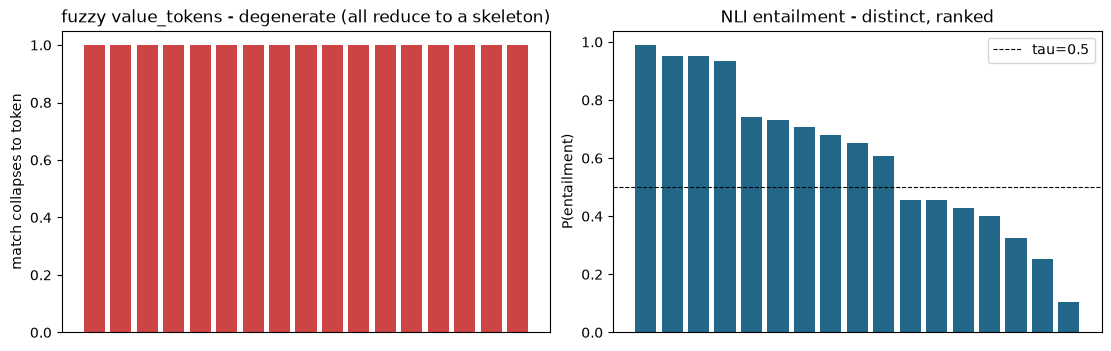

In [8]:
# clause (a) visual: fuzzy is a flat binary skeleton, NLI is a spread
fig,ax=plt.subplots(1,2,figsize=(11,3.4),constrained_layout=True)
ax[0].bar(range(len(rows_a)),[1]*len(rows_a),color="#c44"); ax[0].set_title("fuzzy value_tokens - degenerate (all reduce to a skeleton)")
ax[0].set_ylabel("match collapses to token"); ax[0].set_xticks([])
ax[1].bar(range(len(rows_a)),scores_a,color="#268"); ax[1].axhline(TAU,ls="--",c="k",lw=.8,label=f"tau={TAU}")
ax[1].set_title("NLI entailment - distinct, ranked"); ax[1].set_ylabel("P(entailment)"); ax[1].set_xticks([]); ax[1].legend()
plt.show()

In [9]:
# H172 clause (c) - LATENCY <100ms/pair after warmup
_ctx=["warranty: 2 years unit years device dreamstation cpap standard"]
for _ in range(5): nli_entail("2 years", _ctx)               # warmup
t0=time.time(); N=100
for _ in range(N): nli_entail("2 years", _ctx)
ms_pair=(time.time()-t0)/N*1000
# per-gold full-context cost (many pairs per gold) for transparency
t0=time.time()
for pid,g in golds[:8]: nli_entail(g, ctx_units(pid))
ms_gold=(time.time()-t0)/8*1000
clause_c = ms_pair < 100
rprint(f"[bold cyan]Clause (c)[/bold cyan] single-pair latency {ms_pair:.1f} ms/pair (bar <100) -> "
       f"[{'green' if clause_c else 'red'}]{'PASS' if clause_c else 'FAIL'}[/]  "
       f"[dim](full gold-vs-context = many pairs: {ms_gold:.0f} ms/gold)[/dim]")

Clause (c) single-pair latency 66.5 ms/pair (bar <100) -> PASS  (full gold-vs-context = many pairs: 554 ms/gold)

### H172 clause (b) - 50-pair manual audit

50 `(gold, rendered-context)` pairs: 33 positive-intent (each gold vs its own probe's context) + 17 negative-intent (a gold
paired with a mismatched probe's context, deterministic mapping). **The 50 judgments below were adjudicated by the executor
by reading each rendered context and the gold** (verified against the raw seed renders and propositions - literal value
presence checked in the context, de-spaced forms included). Strict rule: *entailed* means the rendered text actually
contains or implies the gold fact. Each judgment carries a one-line rationale. Agreement = fraction where the NLI decision
(entailment >= tau) matches the manual label. Bar: >=90% (refuted <80%).

In [10]:
# Reconstruct the exact 50 audit pairs (deterministic), attach the executor's manual labels + rationales
pairs=[]
for pid,g in golds: pairs.append(dict(kind="pos", gold=g, src=pid, ctx=pid))
_idxs=list(range(0,len(golds),2))[:17]; _others=[p["id"] for p in gold_probes]
for i in _idxs:
    pid,g=golds[i]; cand=[o for o in _others if o!=pid]; cp=cand[(i*7)%len(cand)]
    pairs.append(dict(kind="neg", gold=g, src=pid, ctx=cp))
assert len(pairs)==50

# Executor manual adjudication (1 = gold fact present/implied in the rendered context, 0 = absent)
ADJ={0:0,1:0,2:1,3:1,4:1,5:1,6:1,7:1,8:1,9:0,10:1,11:1,12:0,13:0,14:1,15:0,16:1,17:1,18:1,19:0,
     20:0,21:0,22:1,23:0,24:1,25:1,26:0,27:1,28:1,29:1,30:0,31:1,32:1,33:0,34:1,35:0,36:0,37:0,
     38:1,39:0,40:0,41:0,42:0,43:0,44:0,45:0,46:0,47:1,48:0,49:1}
RAT={
 0:"40 oz (1130 g) not among retrieved seeds; '1130' absent from context - retrieval miss",
 1:"'40'/'40 oz' absent from P01 seeds - weight spec not retrieved",
 2:"'pressure_range: 4-20 cmh2o' present - entails 4 to 20 cm H2O",
 3:"'<28db at 10 cmh2o' sound-pressure statement present - supports 28 dB(A)",
 4:"'warranty: 2' with warranty_unit=years present",
 5:"'0-45 minute', 'zero to 45 minutes', ramp_period_max=45 present",
 6:"'capacity: 380 ml' present",
 7:"'operating_altitude_max: 2591' present",
 8:"'typical: 9.0w' present",
 9:"SleepStyle 200 dims not retrieved; 275/170/140 absent from P09 seeds",
 10:"'data_storage_sd_card: > 1 year' present verbatim",
 11:"'weight: 1106' unit=g present",
 12:"1130 g (AirSense 11) absent from P11 seeds; '1130' not found",
 13:"28 dB(A) (iBreeze) absent from P12 seeds (Loewenstein / RESmart)",
 14:"'sound_pressure_level_db: 26' present (prisma SMART)",
 15:"3010 absent; only 2591 present in P13",
 16:"'operating_altitude_max: 2591' present",
 17:"'humidifier_capacity_ml: 380' present",
 18:"'water_capacity_ml: 290' present",
 19:"1.98kg absent from P15 seeds",
 20:"only 'manual_version: v2.4' present, no weight 2.4 kg - fuzzy false-positive on '2.4'",
 21:"SleepStyle dims absent from P16 seeds",
 22:"'dimension height/length/width mm: 128/238/178' present",
 23:"iBreeze 0-60 min ramp absent; P17 seeds are all DreamStation",
 24:"'smart_ramp_time: 0 to 45' present",
 25:"'sound_pressure_level: 26.6' present",
 26:"27 dBA absent from P18 seeds",
 27:"'the smartramp mode maintains a constant lower pressure' present verbatim",
 28:"'supports_mode -> autoset for her' present",
 29:"'designed to help patients gradually acclimate' present",
 30:"context has 'pressure oscillations' but not 'amplitude' - amplitude not stated",
 31:"'autoramp with sleep onset detection' present",
 32:"'expiratory pressure relief - makes it easier to breathe out during therapy' present",
 33:"1130 g absent from P02 (DreamStation pressure) context",
 34:"P16 iBreeze 'pressure_range_cmh2o: 4-20' present - value coincides",
 35:"AirStart 10 (P07) context has no warranty statement",
 36:"380 mL absent from P21 (EZ-Start) context",
 37:"9.0W absent from P12 context",
 38:"P02 is DreamStation - shares 'data_storage_sd_card: > 1 year'; present",
 39:"1130 g absent from P17 context",
 40:"P07 has '26.6' (AirStart) not '26 dB(A)' (prisma) - different value",
 41:"2591 absent from P22 (Seattle-PAP) context",
 42:"290 ml absent from P12 context",
 43:"2.4 kg absent from P03 context",
 44:"238*178*128 absent from P18 context",
 45:"0 to 45 ramp absent from P08 (AirSense power) context",
 46:"27 dBA absent from P23 context",
 47:"P13 AirSense context has 'supports_mode -> autoset for her'; present",
 48:"amplitude of oscillations absent from P04 context",
 49:"P18 has 'has_comfort_feature -> expiratory pressure relief' - feature name implies reducing expiratory pressure",
}
assert set(ADJ)==set(range(50)) and set(RAT)==set(range(50))
rprint(f"[cyan]audit set[/cyan] 50 pairs ({sum(1 for p in pairs if p['kind']=='pos')} pos / "
       f"{sum(1 for p in pairs if p['kind']=='neg')} neg); manual entailed={sum(ADJ.values())} / not={50-sum(ADJ.values())}")

audit set 50 pairs (33 pos / 17 neg); manual entailed=25 / not=25

In [11]:
# Score the 50 pairs with the NLI scorer; compare to the manual labels
audit=[]
with Progress() as prog:
    t=prog.add_task("[cyan]audit NLI scoring", total=len(pairs))
    for i,pr in enumerate(pairs):
        sc=nli_entail(pr["gold"], ctx_units(pr["ctx"]))
        audit.append(dict(i=i, kind=pr["kind"], gold=pr["gold"], ctx=pr["ctx"], nli=sc, manual=ADJ[i], rationale=RAT[i]))
        prog.advance(t)
sc=np.array([a["nli"] for a in audit]); lab=np.array([a["manual"] for a in audit])
def agree_at(tau): return float(((sc>=tau).astype(int)==lab).mean())
agree_tau=agree_at(TAU)
taus=np.arange(0.20,0.85,0.01); best_i=int(np.argmax([agree_at(t) for t in taus])); best_tau=float(taus[best_i]); best_agree=agree_at(best_tau)
posS,negS=sc[lab==1],sc[lab==0]
auc=float(np.mean([(a>b)+0.5*(a==b) for a in posS for b in negS]))
clause_b = best_agree>=0.90; refuted_b = best_agree<0.80
rprint(f"[bold cyan]Clause (b)[/bold cyan] agreement@tau{TAU}={agree_tau:.3f} | best={best_agree:.3f}@tau={best_tau:.2f} | "
       f"AUC={auc:.3f} (pos mean {posS.mean():.3f} vs neg mean {negS.mean():.3f})")
rprint(f"  bar >=0.90 -> [{'green' if clause_b else 'red'}]{'PASS' if clause_b else 'FAIL'}[/] | "
       f"refutation bar <0.80 -> [{'red' if refuted_b else 'green'}]{'REFUTED' if refuted_b else 'not refuted'}[/]")
print("\n-- disagreements at best tau (%.2f) --"%best_tau)
for a in audit:
    p=int(a["nli"]>=best_tau)
    if p!=a["manual"]:
        typ="NLI false-POS (absent scored high)" if p==1 else "NLI false-NEG (present scored low)"
        print(f"  #{a['i']:2} nli={a['nli']:.3f} manual={a['manual']} [{typ}] {a['gold'][:26]!r} ctx={a['ctx']} :: {a['rationale'][:60]}")

Clause (b) agreement@tau0.5=0.620 | best=0.780@tau=0.71 | AUC=0.803 (pos mean 0.733 vs neg mean 0.442)

bar >=0.90 -> FAIL | refutation bar <0.80 -> REFUTED


-- disagreements at best tau (0.71) --
  # 3 nli=0.652 manual=1 [NLI false-NEG (present scored low)] '28 dB(A)' ctx=P03 :: '<28db at 10 cmh2o' sound-pressure statement present - suppo
  # 7 nli=0.345 manual=1 [NLI false-NEG (present scored low)] '2,591 m' ctx=P07 :: 'operating_altitude_max: 2591' present
  #12 nli=0.779 manual=0 [NLI false-POS (absent scored high)] '1130 g' ctx=P11 :: 1130 g (AirSense 11) absent from P11 seeds; '1130' not found
  #14 nli=0.457 manual=1 [NLI false-NEG (present scored low)] '26 dB(A)' ctx=P12 :: 'sound_pressure_level_db: 26' present (prisma SMART)
  #16 nli=0.271 manual=1 [NLI false-NEG (present scored low)] '2,591 m' ctx=P13 :: 'operating_altitude_max: 2591' present
  #17 nli=0.400 manual=1 [NLI false-NEG (present scored low)] '380 mL' ctx=P14 :: 'humidifier_capacity_ml: 380' present
  #18 nli=0.455 manual=1 [NLI false-NEG (present scored low)] '290 ml' ctx=P14 :: 'water_capacity_ml: 290' present
  #22 nli=0.193 manual=1 [NLI false-NEG (present scored 

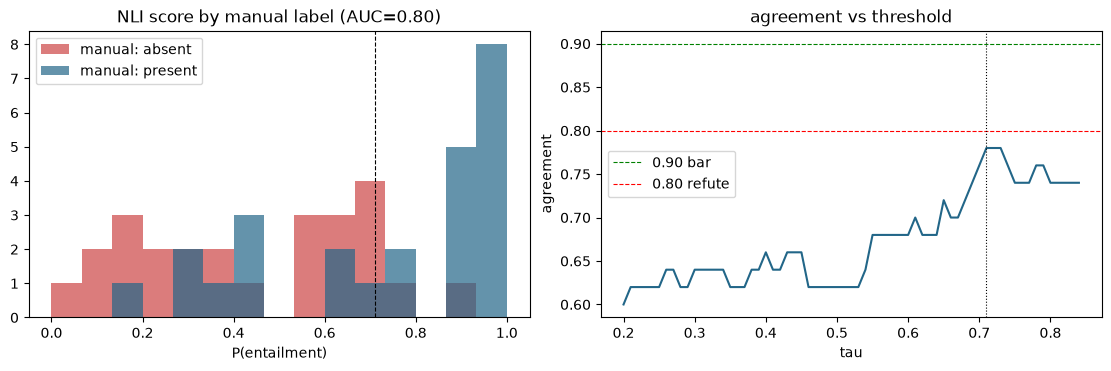

In [12]:
# clause (b) visual - score distributions by manual label + agreement-vs-threshold
fig,ax=plt.subplots(1,2,figsize=(11,3.6),constrained_layout=True)
ax[0].hist(negS,bins=np.linspace(0,1,16),alpha=.7,label="manual: absent",color="#c44")
ax[0].hist(posS,bins=np.linspace(0,1,16),alpha=.7,label="manual: present",color="#268")
ax[0].axvline(best_tau,ls="--",c="k",lw=.8); ax[0].set_title(f"NLI score by manual label (AUC={auc:.2f})")
ax[0].set_xlabel("P(entailment)"); ax[0].legend()
ax[1].plot(taus,[agree_at(t) for t in taus],c="#268"); ax[1].axhline(0.9,ls="--",c="g",lw=.8,label="0.90 bar")
ax[1].axhline(0.8,ls="--",c="r",lw=.8,label="0.80 refute"); ax[1].axvline(best_tau,ls=":",c="k",lw=.8)
ax[1].set_title("agreement vs threshold"); ax[1].set_xlabel("tau"); ax[1].set_ylabel("agreement"); ax[1].legend()
plt.show()

### H172 - re-run H81's headline under the new instrument

Baseline recall and the greedy materialize-view recall-at-knee, computed under fuzzy and under NLI (same seed contexts, same
edit set - carriers proposed by structural reachability, sufficiency credited by each scorer). This shows which direction the
instrument change moves H81's clause (a).

In [13]:
# H81 re-run: baseline recall (three instruments) + greedy recall-at-knee (fuzzy vs NLI)
# baseline
b_fuzzy_seed=present0
b_fuzzy_rp=sum(1 for pid,g in golds if present(g,_norm(" ".join(ctx_units(pid)))))
nli_base={(pid,g):nli_entail(g,ctx_units(pid)) for pid,g in golds}
b_nli_rp=sum(1 for v in nli_base.values() if v>=TAU)
rprint(f"[bold cyan]H81 baseline recall[/bold cyan] fuzzy@seed_render={b_fuzzy_seed}/{n_golds}={b_fuzzy_seed/n_golds:.3f} "
       f"[dim](H81 anchor 0.697)[/dim] | fuzzy@render+prop={b_fuzzy_rp}/{n_golds} | "
       f"NLI@render+prop={b_nli_rp}/{n_golds}={b_nli_rp/n_golds:.3f}")

# candidate materialize-view edits: nearest carrier per fuzzy-missing gold (H81 machinery)
missing=[(pid,g,seeds_by[pid]) for pid,g in golds if not present(g,seed_ctx(pid))]
fs={nid:full_surface(nid) for nid in node}
def carriers_of(g): return [nid for nid,t in fs.items() if present(g,t)]
def hop_of(c,vec):
    ss=set(vec)
    if c in ss: return 0
    if adj[c]&ss: return 1
    two=set().union(*[adj[s0] for s0 in vec]) if vec else set()
    return 2 if adj[c]&two else 9
def nearest_carrier(g,vec):
    cs=carriers_of(g)
    if not cs: return None
    cs.sort(key=lambda c:(hop_of(c,vec),TOK(view_render(c)))); return cs[0]
by_pc=defaultdict(list)
for pid,g,vec in missing:
    c=nearest_carrier(g,vec)
    if c is not None: by_pc[(pid,c)].append(g)
edits=[dict(pid=pid,carrier=c,golds=gs,cost=TOK(view_render(c)),ctype=prim_type[c]) for (pid,c),gs in by_pc.items()]
T0=sum(TOK(" ".join(seed_render(n) for n in seeds_by[p["id"]])) for p in gold_probes)
LAM=0.15*present0/T0
vr_ent={(e["pid"],g,e["carrier"]):nli_entail(g,[view_render(e["carrier"])]) for e in edits for g in e["golds"]}
def recall_tokens(applied,scorer):
    tokens=T0; extra=defaultdict(list)
    for e in applied: extra[e["pid"]].append(e["carrier"]); tokens+=e["cost"]
    pres=0
    for pid,g in golds:
        if scorer=="fuzzy":
            cn=_norm(" ".join(seed_render(n) for n in seeds_by[pid])+" "+" ".join(view_render(c) for c in extra.get(pid,[])))
            pres+=present(g,cn)
        else:
            add=max([vr_ent.get((pid,g,c),0.0) for c in extra.get(pid,[])]+[0.0])
            pres+=(max(nli_base[(pid,g)],add)>=TAU)
    return pres,tokens
def greedy(scorer):
    applied=[]; remaining=list(edits); cp,ct=recall_tokens([],scorer); traj=[(cp/n_golds,0.0)]
    while remaining:
        best=None
        for e in remaining:
            npr,nt=recall_tokens(applied+[e],scorer); dphi=(npr-LAM*nt)-(cp-LAM*ct)
            if best is None or dphi/e["cost"]>best[0]: best=(dphi/e["cost"],dphi,e)
        _,dphi,e=best
        if dphi<=0: break
        applied.append(e); remaining.remove(e); cp,ct=recall_tokens(applied,scorer); traj.append((cp/n_golds,(ct-T0)/T0))
    r10=max(rr for rr,tk in traj if tk<=0.10+1e-9); cross=next((tk for rr,tk in traj if rr>=0.90),None)
    return r10,cross,traj[-1][0]
h81={}
for scorer in ["fuzzy","nli"]:
    r10,cross,fin=greedy(scorer); h81[scorer]=dict(r10=r10,cross=cross,final=fin)
    rprint(f"  greedy[{scorer:5}] recall@+10%={r10:.3f}  cross 0.9 @ {'+%.1f%%'%(cross*100) if cross is not None else 'never'}  final={fin:.3f}")
rprint(f"[dim]H81 anchor (fuzzy): recall@+10%=0.879, crosses 0.9 at +10.9%[/dim]")

H81 baseline recall fuzzy@seed_render=23/33=0.697 (H81 anchor 0.697) | fuzzy@render+prop=25/33 | 
NLI@render+prop=21/33=0.636

greedy recall@+10%=0.879  cross 0.9 @ +10.9%  final=1.000

greedy recall@+10%=0.636  cross 0.9 @ never  final=0.636

H81 anchor (fuzzy): recall@+10%=0.879, crosses 0.9 at +10.9%

In [14]:
# H172 verdict
h172_verdict = "REFUTED" if refuted_b else ("CONFIRMED" if (degenerate and clause_b and clause_c) else "PARTIALLY CONFIRMED")
rprint(f"[bold]H172 clauses[/bold]  (a) non-degenerate: [{'green' if degenerate else 'red'}]{'PASS' if degenerate else 'FAIL'}[/]  "
       f"(b) audit agreement {best_agree:.2f} (bar .90 / refute .80): [{'green' if clause_b else 'red'}]{'PASS' if clause_b else 'FAIL'}[/]  "
       f"(c) latency {ms_pair:.0f}ms: [{'green' if clause_c else 'red'}]{'PASS' if clause_c else 'FAIL'}[/]")
rprint(f"[bold cyan]R18-H172 VERDICT[/bold cyan] -> [{'red' if h172_verdict=='REFUTED' else 'green'}]{h172_verdict}[/] "
       f"[dim]- NLI is non-degenerate and fast but cannot verify exact factual presence in JSON-spec renders "
       f"(present numerics score low, absent look-alikes score high); a value-extraction comparator is the registered successor[/dim]")

H172 clauses  (a) non-degenerate: PASS  (b) audit agreement 0.78 (bar .90 / refute .80): FAIL  (c) latency 67ms: 
PASS

R18-H172 VERDICT -> REFUTED - NLI is non-degenerate and fast but cannot verify exact factual presence in JSON-spec 
renders (present numerics score low, absent look-alikes score high); a value-extraction comparator is the 
registered successor

## R18-H176 - the graded gradient

H172's clause (b) failed, so per the registration H176 uses the **token-coverage graded fallback** (not entailment
probability): per-gold sufficiency = fraction of the gold's content tokens present in the context, a continuous [0,1]
signal. Per-type residual gradient = max graded Delta-Phi over materialize edits whose carrier is of that type (H85's
structure, graded). Clauses: variance restored (**CoV >= 0.2** across types) and independence survives (**|r| < 0.3** vs
per-type Good-Turing missing mass, bootstrap CI excluding |r| > 0.5). Missing-mass table reused from H85.

In [15]:
# Token-coverage graded scorer + per-type gradient vs Good-Turing missing mass (H85 table)
def content_toks(g):
    vt=value_tokens(g)
    if vt: return [re.sub(r"[\s,()]","",_norm(t)) for t in vt]
    return sorted(set(re.findall(r"[a-z][a-z0-9\-]{2,}",_norm(g))))
def coverage(g,ctx_norm):
    ct=content_toks(g)
    if not ct: return 0.0
    sq=re.sub(r"[\s,()]","",ctx_norm)
    return sum(1 for t in ct if t in ctx_norm or t in sq)/len(ct)

# per-type Good-Turing missing mass (H85 cell: prop_* key inventory, n1/N)
typ_keys=defaultdict(list)
for r in ents:
    for k in r["props"]:
        if k.startswith("prop_"): typ_keys[prim_type[r["id"]]].append(k)
def good_turing(keys):
    c=Counter(keys); Nn=sum(c.values()); return (sum(1 for v in c.values() if v==1)/Nn) if Nn else 0.0
mm_by_type={t:good_turing(ks) for t,ks in typ_keys.items()}

base_ctx={pid:seed_ctx(pid) for pid,_ in golds}
def graded_gain(e):
    add=_norm(view_render(e["carrier"]))
    g=sum(coverage(gg, base_ctx[e["pid"]]+" "+add)-coverage(gg, base_ctx[e["pid"]]) for gg in e["golds"])
    return g - LAM*e["cost"]
type_grad=defaultdict(float)
for e in edits: type_grad[e["ctype"]]=max(type_grad[e["ctype"]], graded_gain(e))
tt=[t for t in mm_by_type]; mm=np.array([mm_by_type[t] for t in tt]); gr=np.array([type_grad.get(t,0.0) for t in tt])
pos=gr[gr>0]
cov_all=float(np.std(gr)/np.mean(gr)) if np.mean(gr) else float("nan")
cov_pos=float(np.std(pos)/np.mean(pos)) if len(pos)>1 and np.mean(pos) else float("nan")
r_all=float(np.corrcoef(mm,gr)[0,1])
rng=np.random.default_rng(42); bs=[]
for _ in range(5000):
    idx=rng.integers(0,len(tt),len(tt))
    if np.std(mm[idx])>0 and np.std(gr[idx])>0: bs.append(np.corrcoef(mm[idx],gr[idx])[0,1])
lo,hi=np.percentile(bs,[2.5,97.5])
var_ok = cov_pos>=0.2 or cov_all>=0.2
ci_excl_strong = (abs(lo)<=0.5 and abs(hi)<=0.5)
indep_ok = abs(r_all)<0.3
rprint(f"[bold cyan]H176 graded per-type gradient[/bold cyan] {int((gr>0).sum())}/{len(tt)} types positive, max {gr.max():.3f}")
rprint(f"  CoV all types={cov_all:.3f}  CoV positive types={cov_pos:.3f}  (bar >=0.2) -> "
       f"[{'green' if var_ok else 'red'}]{'PASS' if var_ok else 'FAIL'}[/]")
rprint(f"  r(missmass, grad)={r_all:+.3f} (bar |r|<0.3) -> [{'green' if indep_ok else 'red'}]{'PASS' if indep_ok else 'FAIL'}[/]  "
       f"bootstrap95%CI=[{lo:+.3f},{hi:+.3f}] (excludes |r|>0.5?) -> [{'green' if ci_excl_strong else 'red'}]{'YES' if ci_excl_strong else 'NO'}[/]")
print(f"\n{'type':20}{'missmass':>10}{'graded grad':>13}")
for t,m,g in sorted(zip(tt,mm,gr),key=lambda x:-x[2]):
    if g>0: print(f"{t:20}{m:>10.3f}{g:>13.4f}")
rprint(f"[dim]H85 binary anchor: per-type grad ~0.99 uniform (variance collapse), r_all=-0.184[/dim]")

H176 graded per-type gradient 6/20 types positive, max 0.986

CoV all types=1.572  CoV positive types=0.204  (bar >=0.2) -> PASS

r(missmass, grad)=-0.260 (bar |r|<0.3) -> PASS  bootstrap95%CI=[-0.575,+0.160] (excludes |r|>0.5?) -> NO


type                  missmass  graded grad
Software                 0.327       0.9862
Specification            0.342       0.9704
Accessory                0.124       0.9535
ComfortFeature           0.638       0.9374
CPAPDevice               0.428       0.8163
ClinicalFeature          0.710       0.4877


H85 binary anchor: per-type grad ~0.99 uniform (variance collapse), r_all=-0.184

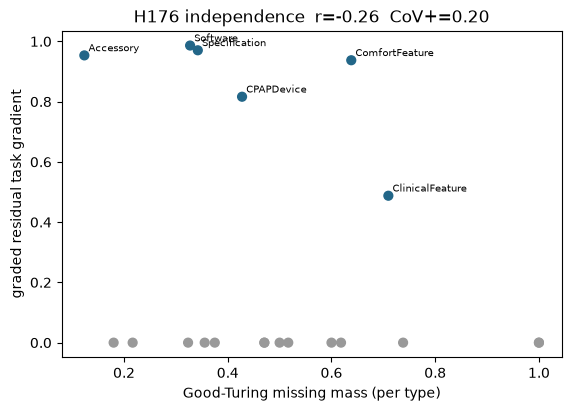

R18-H176 VERDICT -> PARTIALLY CONFIRMED

In [16]:
# H176 scatter
fig,ax=plt.subplots(figsize=(5.6,4),constrained_layout=True)
ax.scatter(mm,gr,c=["#268" if g>0 else "#999" for g in gr],s=40)
for t,m,g in zip(tt,mm,gr):
    if g>0: ax.annotate(t,(m,g),fontsize=7,xytext=(3,3),textcoords="offset points")
ax.set_xlabel("Good-Turing missing mass (per type)"); ax.set_ylabel("graded residual task gradient")
ax.set_title(f"H176 independence  r={r_all:+.2f}  CoV+={cov_pos:.2f}"); plt.show()

h176_verdict = "CONFIRMED" if (var_ok and indep_ok and ci_excl_strong) else "PARTIALLY CONFIRMED"
rprint(f"[bold cyan]R18-H176 VERDICT[/bold cyan] -> [{'green' if h176_verdict=='CONFIRMED' else 'yellow'}]{h176_verdict}[/]")

In [17]:
# Machine-readable report
stamp=datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
report=dict(
  round="R18", batch="H172+H176", utc=stamp, graph="neo4j2", gold_set="original-33",
  nli_model=NLI_MODEL, gpu="RTX5000Ada/sm89", dtype="fp16", attn="eager", tau=TAU,
  H172=dict(
    clause_a_nondegenerate=bool(degenerate), short_golds=len(short_golds),
    nli_score_range=[float(scores_a.min()),float(scores_a.max())], distinct_scores=int(len(set(np.round(scores_a,3)))),
    clause_b_audit=dict(n=50, manual_present=int(sum(ADJ.values())), agreement_at_tau=agree_tau,
                        best_agreement=best_agree, best_tau=best_tau, auc=auc,
                        pass_bar_90=bool(clause_b), refuted_bar_80=bool(refuted_b)),
    clause_c_ms_per_pair=ms_pair, clause_c_pass=bool(clause_c),
    h81_rerun=dict(baseline=dict(fuzzy_seed_render=b_fuzzy_seed, fuzzy_render_prop=b_fuzzy_rp, nli_render_prop=b_nli_rp,
                                 n_golds=n_golds),
                   greedy=h81),
    verdict=h172_verdict),
  H176=dict(scorer="token-coverage-fallback", types=len(tt), types_positive=int((gr>0).sum()),
    cov_all=cov_all, cov_positive=cov_pos, var_restored=bool(var_ok),
    r_missmass_grad=r_all, indep_ok=bool(indep_ok), bootstrap_ci=[float(lo),float(hi)],
    ci_excludes_strong=bool(ci_excl_strong), verdict=h176_verdict))
outp=Path("../reports")/f"entailment-r18-{stamp}.json"; outp.write_text(json.dumps(report,indent=2,default=str))
rprint(f"[green]report written[/green] {outp}")
rprint(report)

report written ../reports/entailment-r18-20260707T140920Z.json

{
    'round': 'R18',
    'batch': 'H172+H176',
    'utc': '20260707T140920Z',
    'graph': 'neo4j2',
    'gold_set': 'original-33',
    'nli_model': 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
    'gpu': 'RTX5000Ada/sm89',
    'dtype': 'fp16',
    'attn': 'eager',
    'tau': 0.5,
    'H172': {
        'clause_a_nondegenerate': True,
        'short_golds': 17,
        'nli_score_range': [0.10389741510152817, 0.9893038272857666],
        'distinct_scores': 17,
        'clause_b_audit': {
            'n': 50,
            'manual_present': 25,
            'agreement_at_tau': 0.62,
            'best_agreement': 0.78,
            'best_tau': 0.7100000000000004,
            'auc': 0.8032,
            'pass_bar_90': False,
            'refuted_bar_80': True
        },
        'clause_c_ms_per_pair': 66.53918743133545,
        'clause_c_pass': True,
        'h81_rerun': {
            'baseline': {'fuzzy_seed_render': 23, 'fuzzy_render_prop': 25, 'nli_render_prop': 21, 'n_golds': 33},
            'greedy': {
                'fuzzy': {'r10': 0.8787878787878788, 'cross': 0.10926780222379938, 'final': 1.0},
                'nli': {'r10': 0.6363636363636364, 'cross': None, 'final': 0.6363636363636364}
            }
        },
        'verdict': 'REFUTED'
    },
    'H176': {
        'scorer': 'token-coverage-fallback',
        'types': 20,
        'types_positive': 6,
        'cov_all': 1.5721156825173481,
        'cov_positive': 0.20362788552920752,
        'var_restored': True,
        'r_missmass_grad': -0.2596003851440427,
        'indep_ok': True,
        'bootstrap_ci': [-0.5746475298773548, 0.16027756561253997],
        'ci_excludes_strong': False,
        'verdict': 'PARTIALLY CONFIRMED'
    }
}